In [1]:
import strawberryfields as sf
from strawberryfields.ops import *
import numpy as np
from scipy.special import erfc
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from helper_functions import protocols
from scipy.optimize import curve_fit
import math

## cs

In [ ]:
def phase_diffused_cs(alphas: np.array, sigma: float, num_samples: int):
    
    p_err = np.zeros((len(alphas)))
    
    for i in range(len(alphas)):
        phis = np.random.normal(0, sigma, size=num_samples)
        wrong_sign_counter = 0

        for phi in phis:
            coherent_sign = np.random.choice([1, -1])
            prog = sf.Program(1)

            with prog.context as q:
                Dgate(coherent_sign*alphas[i]) | q
                Rgate(phi) | q
                MeasureHomodyne(0) | q

            eng = sf.Engine("gaussian")
            result = eng.run(prog)
            result_sign = np.sign(result.samples[0][0])

            if (result_sign>=0 and coherent_sign<0) or (result_sign<0 and coherent_sign>0):
                    wrong_sign_counter+= 1
            p_err[i] = wrong_sign_counter/num_samples

    return p_err

        
    

## Produce data

In [5]:
sigmas = np.linspace(0, 1, 5)
alpha_grid = np.linspace(0,1,30)
num_samples = 3000

p_err_cs_list = []

for i, sigma in enumerate(sigmas):

    p_err_cs_list.append(phase_diffused_cs(alpha_grid, sigma, num_samples))
    print(f"\rProgress: {i+1}/{len(sigmas)}", end="", flush=True)

np.savez(f"data/perr_data_phase_diff_cs_a{len(alpha_grid)}_S{num_samples}_sigmas{len(sigmas)}.npz", alpha_grid=alpha_grid, p_err_cs_list=p_err_cs_list, sigmas = sigmas)

Progress: 5/5

## Load data

In [38]:
data = np.load(f"data/perr_data_phase_diff_cs_a30_S3000_sigmas5.npz")


alpha_cs = data["alpha_grid"]
p_err_cs_list = data["p_err_cs_list"]
sigmas_cs = data["sigmas"]

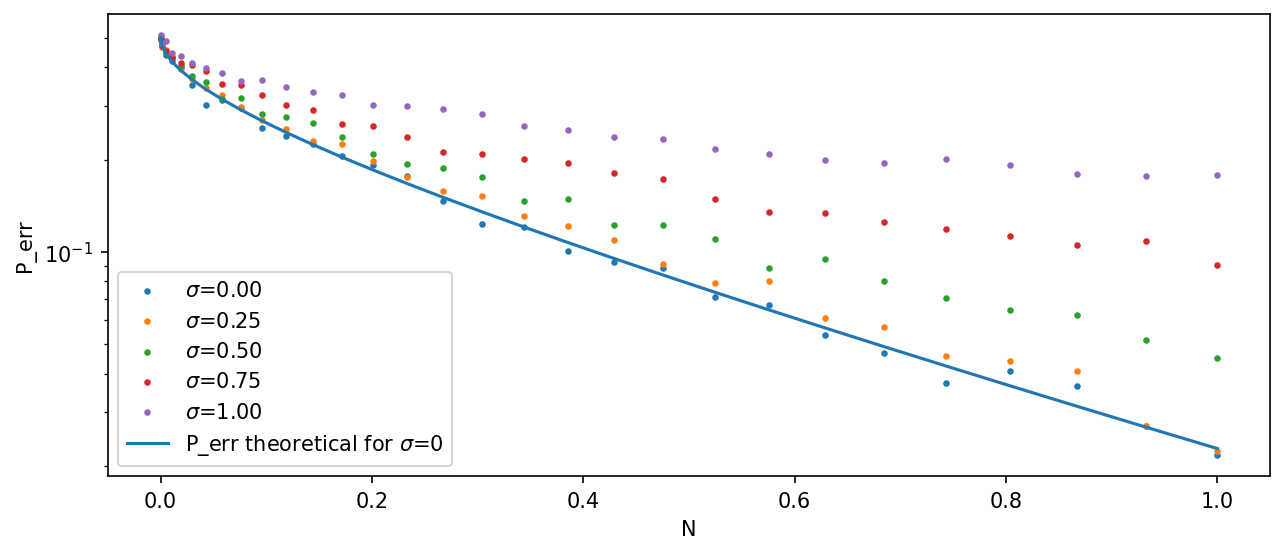

In [30]:
fig = plt.figure(figsize=(10,4), dpi=150)
N = alpha_cs**2
for i, p_err in enumerate(p_err_cs_list):
    plt.scatter(N, p_err, label = fr'$\sigma$={sigmas_cs[i]:.2f}', s=4.5)
plt.xlabel('N')
plt.ylabel('P_err')
plt.plot(N, protocols.perr_homodyne(N, 0), label=r'P_err theoretical for $\sigma$=0')
plt.yscale('log')
plt.legend()

## DSS

In [31]:
def phase_diffused_dss(N_grid:np.array, beta_grid:np.array, sigma, num_samples:int):

    #Calculation of error probability
    #============================================
    p_err = np.zeros((len(N_grid), len(beta_grid)))
    
    for i,N in enumerate(N_grid):
        alphas = np.sqrt(N*(1-beta_grid)) 
        print(f"\rProgress: {i+1}/{len(N_grid)}", end="", flush=True)
        
        for k, beta in enumerate(beta_grid):
            wrong_sign_counter = 0
            r_s = math.asinh(np.sqrt(N*beta))
            phis = np.random.normal(0, sigma, size=num_samples)
            for phi in phis:
                coherent_sign = np.random.choice([1, -1])
                prog = sf.Program(1)
                with prog.context as q:
                    Sgate(r_s, 0) | q[0] 
                    Dgate(coherent_sign*alphas[k]) | q
                    Rgate(phi) | q
                    MeasureHomodyne(0) | q

                eng = sf.Engine("gaussian")
                result = eng.run(prog)
                result_sign = np.sign(result.samples[0][0])

                if (result_sign>=0 and coherent_sign<0) or (result_sign<0 and coherent_sign>0):
                        wrong_sign_counter+= 1
                p_err[i][k] = wrong_sign_counter/num_samples
    return p_err

## Produce data

In [34]:
# Parameters
N = np.linspace(0, 2.0, 20)
beta = np.linspace(0.0, 1.0, 20)

sigma = 0.1
num_samples = 2000

# Compute error probabilities
p_err_dss = phase_diffused_dss(N, beta, sigma, num_samples)

# Create meshgrid for plotting
N_grid, beta_grid = np.meshgrid(N, beta, indexing="ij")

np.savez(f"data/perr_data_phase_diff_dss_N{len(N)}_b{len(beta)}_S{num_samples}_sigma{sigma}.npz", N=N, beta = beta, p_err_dss=p_err_dss, sigma = sigma)


Progress: 20/20

## Load data

In [39]:
data = np.load(f"data/perr_data_phase_diff_dss_N20_b20_S2000_sigma0.1.npz")

N_dss = data["N"]
beta_dss = data["beta"]
p_err_dss = data["p_err_dss"]
sigma_dss = data["sigma"]

In [37]:
# Flatten grid for scatter points
N_grid, beta_grid = np.meshgrid(N_dss, beta_dss, indexing="ij")

fig = go.Figure()

fig.add_trace(go.Scatter3d(x=N_grid.ravel(), y=beta_grid.ravel(), z=p_err_dss.ravel(), mode="markers", marker=dict(size=4,color=p_err_dss.ravel(),
            colorscale="Viridis", colorbar=dict(title=r"P_err"), opacity=0.8), name="Simulation"))

fig.update_layout(
    title=rf"Phase-diffused DSS (σ={sigma})", scene=dict(xaxis_title="N", yaxis_title=r"β", zaxis=dict(title="P_err", type='log')), width=900, height=800)

fig.show()